# 02 - Band Gap Prediction

**Goal:** build a machine learning model to predict band gap from composition and structural features, applying a reproducible data science workflow.

**Skills covered:**
- Feature engineering from chemical composition (pymatgen)
- Handling categorical + numeric features
- Baseline → advanced model comparison
- Cross-validation and regression metrics (R², MAE, RMSE)
- Feature importance analysis

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pymatgen.core import Composition, Element
from pymatgen.symmetry.groups import SpaceGroup
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
np.random.seed(42)

In [2]:
ROOT = Path('..').resolve()
df = pd.read_csv(ROOT / 'data' / 'processed' / 'mp_oxides_clean.csv')
print(f'Loaded {len(df)} materials')
df.head()

Loaded 1000 materials


,material_id,formula,space_group,crystal_system,formation_energy_per_atom,band_gap,density,nsites,is_stable,energy_above_hull
0,mp-1523737,NClO,P2_1/c,Monoclinic,0.090138,2.0666,1.812475,12,False,0.159467
1,mp-1567687,V3OF7,C2/m,Monoclinic,-3.022540,1.3813,3.215234,22,False,0.096936
2,mp-1568124,V3OF7,P-1,Triclinic,-3.014306,1.3700,3.227839,22,False,0.105170
3,mp-1568829,Fe4OF6,P1,Triclinic,-2.323263,2.6285,4.420859,22,False,0.065270
4,mp-1569012,Fe4OF6,Pm,Monoclinic,-2.313648,2.4446,4.482592,22,False,0.074885


In [3]:
# Inspect target and missing values
print('Missing values per column:')
print(df.isna().sum())
print()
print(f'Band gap range: {df["band_gap"].min():.2f} - {df["band_gap"].max():.2f} eV')
print(f'Materials with band_gap=0 (metals): {(df["band_gap"] == 0).sum()}')

Missing values per column:
material_id                  0
formula                      0
space_group                  0
crystal_system               0
formation_energy_per_atom    0
band_gap                     0
density                      0
nsites                       0
is_stable                    0
energy_above_hull            0
dtype: int64

Band gap range: 0.00 - 8.17 eV
Materials with band_gap=0 (metals): 350


## 1. Feature Engineering from Composition

We parse each formula with pymatgen and derive chemical descriptors:
- electronegativity statistics
- atomic number statistics
- number of elements
- total electrons

In [4]:
def formula_to_features(formula):
    comp = Composition(formula)
    ens = [Element(el).X for el in comp]
    zs = [Element(el).Z for el in comp]
    return {
        'n_elements': len(comp),
        'avg_electroneg': comp.average_electroneg,
        'std_electroneg': np.std(ens),
        'range_electroneg': max(ens) - min(ens),
        'avg_atomic_number': np.mean(zs),
        'total_electrons': comp.total_electrons,
    }

feat = pd.DataFrame(df['formula'].apply(formula_to_features).tolist())
df2 = pd.concat([df, feat], axis=1)
df2.head()

,material_id,formula,space_group,crystal_system,formation_energy_per_atom,band_gap,density,nsites,is_stable,energy_above_hull,n_elements,avg_electroneg,std_electroneg,range_electroneg,avg_atomic_number,total_electrons
0,mp-1523737,NClO,P2_1/c,Monoclinic,0.090138,2.0666,1.812475,12,False,0.159467,3,3.213333,0.167597,0.40,10.666667,32.0
1,mp-1567687,V3OF7,C2/m,Monoclinic,-3.022540,1.3813,3.215234,22,False,0.096936,3,3.290000,1.004999,2.35,13.333333,140.0
2,mp-1568124,V3OF7,P-1,Triclinic,-3.014306,1.3700,3.227839,22,False,0.105170,3,3.290000,1.004999,2.35,13.333333,140.0
3,mp-1568829,Fe4OF6,P1,Triclinic,-2.323263,2.6285,4.420859,22,False,0.065270,3,3.149091,0.913248,2.15,14.333333,166.0
4,mp-1569012,Fe4OF6,Pm,Monoclinic,-2.313648,2.4446,4.482592,22,False,0.074885,3,3.149091,0.913248,2.15,14.333333,166.0


In [5]:
# Encode space group as its crystallographic Hermann-Mauguin number
def sg_to_number(symbol):
    try:
        return SpaceGroup(symbol).int_number
    except Exception:
        return float('nan')

df2['spacegroup_num'] = df2['space_group'].apply(sg_to_number)

numeric_features = [
    'formation_energy_per_atom', 'density', 'nsites',
    'energy_above_hull', 'n_elements', 'avg_electroneg',
    'std_electroneg', 'range_electroneg', 'avg_atomic_number',
    'total_electrons', 'spacegroup_num'
]
categorical_features = ['crystal_system']

X = df2[numeric_features + categorical_features]
y = df2['band_gap']

print(f'Features: {len(numeric_features)} numeric + {len(categorical_features)} categorical')
print(f'Target: {len(y)} samples')
X.head()

Features: 11 numeric + 1 categorical
Target: 1000 samples


,formation_energy_per_atom,density,nsites,energy_above_hull,n_elements,avg_electroneg,std_electroneg,range_electroneg,avg_atomic_number,total_electrons,spacegroup_num,crystal_system
0,0.090138,1.812475,12,0.159467,3,3.213333,0.167597,0.40,10.666667,32.0,14,Monoclinic
1,-3.022540,3.215234,22,0.096936,3,3.290000,1.004999,2.35,13.333333,140.0,12,Monoclinic
2,-3.014306,3.227839,22,0.105170,3,3.290000,1.004999,2.35,13.333333,140.0,2,Triclinic
3,-2.323263,4.420859,22,0.065270,3,3.149091,0.913248,2.15,14.333333,166.0,1,Triclinic
4,-2.313648,4.482592,22,0.074885,3,3.149091,0.913248,2.15,14.333333,166.0,6,Monoclinic


## 2. Model Pipeline & Evaluation

We compare 3 models with 5-fold cross-validation:
- **Ridge regression** (baseline)
- **Random Forest**
- **Histogram Gradient Boosting**

In [6]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ]), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])

models = {
    'Ridge': Pipeline([('preproc', preprocessor), ('model', Ridge(alpha=1.0))]),
    'RandomForest': Pipeline([('preproc', preprocessor), ('model', RandomForestRegressor(n_estimators=200, random_state=42))]),
    'GradientBoost': Pipeline([('preproc', preprocessor), ('model', HistGradientBoostingRegressor(random_state=42))]),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}
for name, pipe in models.items():
    scores_r2 = cross_val_score(pipe, X, y, cv=cv, scoring='r2')
    scores_mae = -cross_val_score(pipe, X, y, cv=cv, scoring='neg_mean_absolute_error')
    scores_rmse = -cross_val_score(pipe, X, y, cv=cv, scoring='neg_root_mean_squared_error')
    results[name] = {
        'R2_mean': scores_r2.mean(), 'R2_std': scores_r2.std(),
        'MAE_mean': scores_mae.mean(), 'RMSE_mean': scores_rmse.mean(),
    }

results_df = pd.DataFrame(results).T
results_df.round(3)

,R2_mean,R2_std,MAE_mean,RMSE_mean
Ridge,0.296,0.062,0.906,1.182
RandomForest,0.699,0.080,0.457,0.765
GradientBoost,0.708,0.074,0.453,0.753


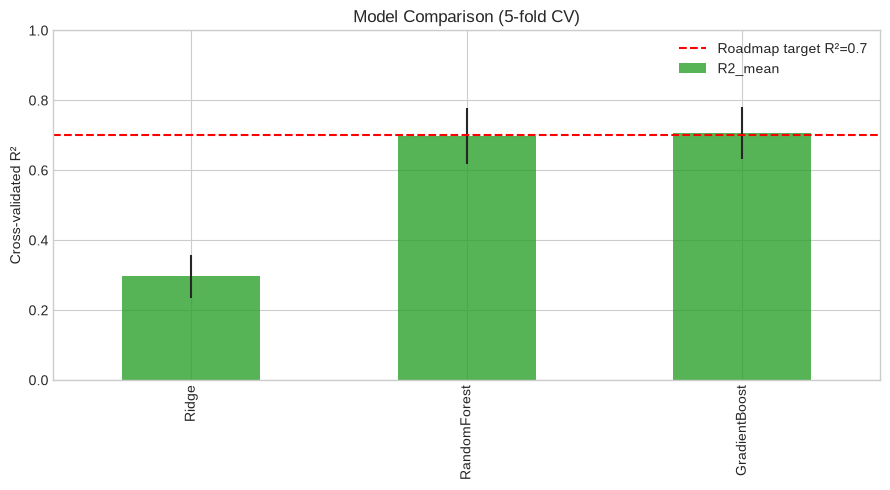

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
results_df[['R2_mean']].plot(kind='bar', yerr=[results_df['R2_std']], ax=ax, legend=False, color='tab:green', alpha=0.8)
ax.axhline(0.7, color='red', linestyle='--', label='Roadmap target R²=0.7')
ax.set_ylabel('Cross-validated R²')
ax.set_ylim(0, 1)
ax.set_title('Model Comparison (5-fold CV)')
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Best Model Analysis

Best model: GradientBoost
Train  R²=0.958, MAE=0.178 eV, RMSE=0.291 eV


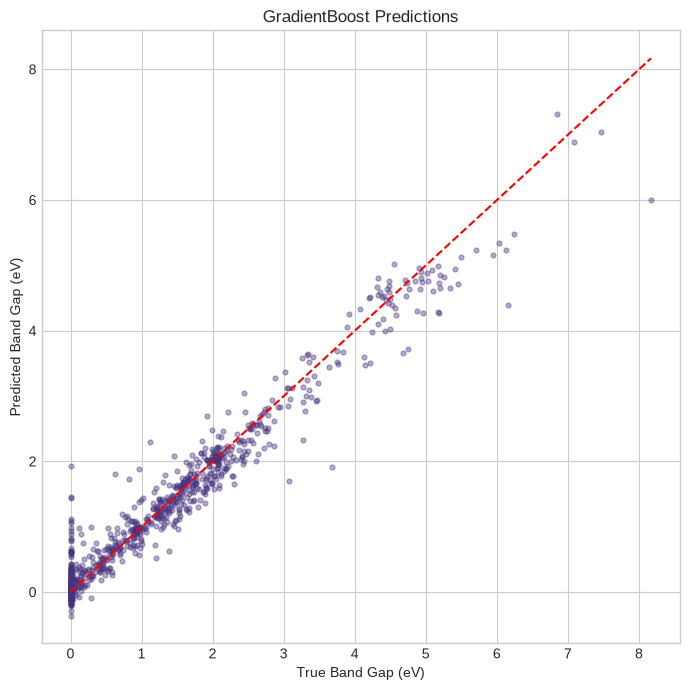

In [8]:
best_name = results_df['R2_mean'].idxmax()
best_pipe = models[best_name]
best_pipe.fit(X, y)
preds = best_pipe.predict(X)

r2 = r2_score(y, preds)
mae = mean_absolute_error(y, preds)
rmse = np.sqrt(mean_squared_error(y, preds))
print(f'Best model: {best_name}')
print(f'Train  R²={r2:.3f}, MAE={mae:.3f} eV, RMSE={rmse:.3f} eV')

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y, preds, alpha=0.4, s=12)
ax.plot([0, y.max()], [0, y.max()], 'r--')
ax.set_xlabel('True Band Gap (eV)')
ax.set_ylabel('Predicted Band Gap (eV)')
ax.set_title(f'{best_name} Predictions')
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'pred_vs_true.png', dpi=150, bbox_inches='tight')
plt.show()

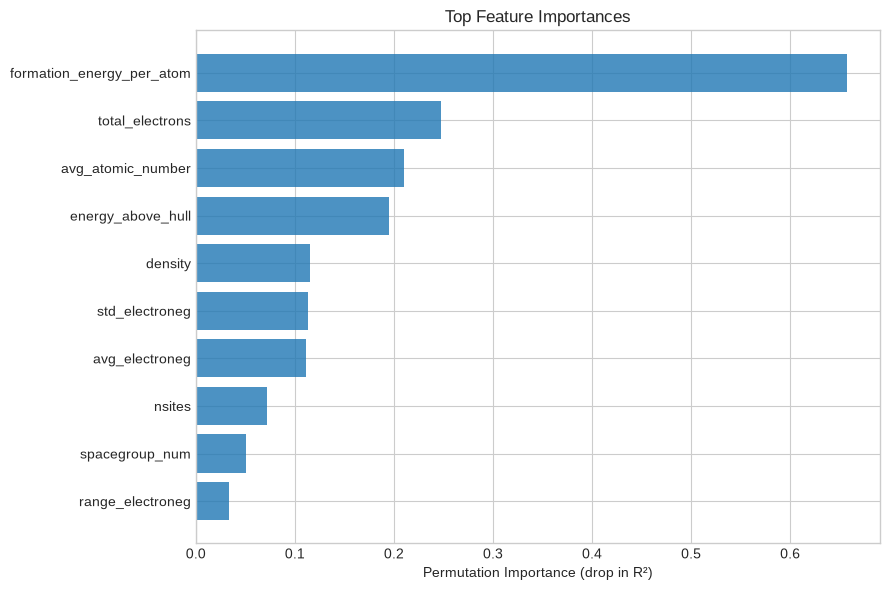

,feature,importance
0,formation_energy_per_atom,0.657797
9,total_electrons,0.247521
8,avg_atomic_number,0.210035
3,energy_above_hull,0.195397
1,density,0.115268
6,std_electroneg,0.113215
5,avg_electroneg,0.111517
2,nsites,0.072046
10,spacegroup_num,0.050815
7,range_electroneg,0.033888


In [9]:
from sklearn.inspection import permutation_importance

# Permutation importance works for any model
preproc_fitted = best_pipe.named_steps['preproc']
X_processed = preproc_fitted.transform(X)

num_names = numeric_features
cat_names = preproc_fitted.named_transformers_['cat'].get_feature_names_out()
all_names = num_names + list(cat_names)

imp = permutation_importance(best_pipe.named_steps['model'], X_processed, y, n_repeats=10, random_state=42)
imp_df = pd.DataFrame({'feature': all_names, 'importance': imp.importances_mean}).sort_values('importance', ascending=False)
imp_df.to_csv(ROOT / 'data' / 'processed' / 'feature_importances.csv', index=False)

top = imp_df.head(10)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top['feature'][::-1], top['importance'][::-1], color='tab:blue', alpha=0.8)
ax.set_xlabel('Permutation Importance (drop in R²)')
ax.set_title('Top Feature Importances')
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()
imp_df